# Régression polynomiale (Prédiction du salaire)

In [1]:
# Importez les libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
df_sal = pd.read_csv("DB/Position_Salaries.csv")
df_sal

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


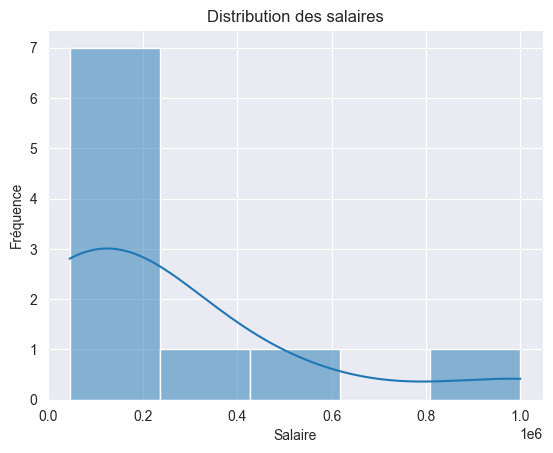

In [2]:
sns.histplot(df_sal["Salary"], kde=True)
plt.title("Distribution des salaires")
plt.xlabel("Salaire")
plt.ylabel("Fréquence")
plt.show()

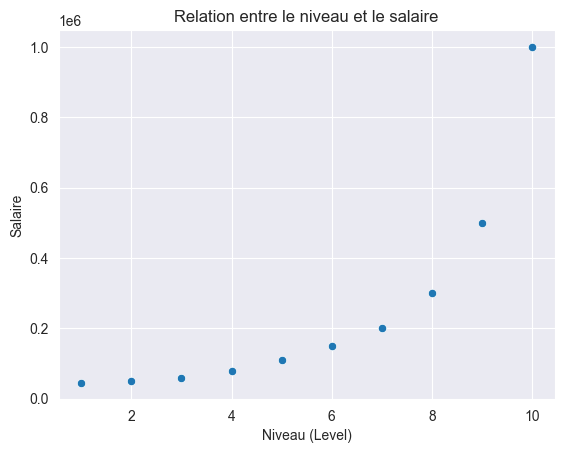

In [3]:
sns.scatterplot(data=df_sal, x="Level", y="Salary")
plt.title("Relation entre le niveau et le salaire")
plt.xlabel("Niveau (Level)")
plt.ylabel("Salaire")
plt.show()

✔ Relation très clairement croissante

On observe que lorsque le niveau augmente, le salaire augmente également, ce qui indique une relation positive.

✔ Mais pas linéaire

La progression n’est pas régulière :

les premiers niveaux (1 → 4) augmentent lentement,

puis l’augmentation devient très forte (8 → 10 surtout).

* Cela suggère une croissance exponentielle du salaire selon le niveau, ce qui est courant dans les grandes organisations où les postes très haut placés (C-level, CEO) gagnent beaucoup plus que les niveaux intermédiaires.

✔ Conclusion

Le scatter montre une courbe fortement non linéaire, ce qui signifie que pour modéliser la relation salaire-niveau, une régression polynomiale ou une SVR serait plus adaptée qu’une simple régression linéaire.

In [4]:
X = df_sal.iloc[:, 1:-1].values  # independent 
y = df_sal.iloc[:, -1].values  # dependent 
# Train linear regression model  
lr = LinearRegression()
lr.fit(X, y)
# Train polynomial regression model  
pr = PolynomialFeatures(degree = 4)
X_poly = pr.fit_transform(X)
lr_2 = LinearRegression()
lr_2.fit(X_poly, y) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# TEST 
y_pred_lr = lr.predict(X)           # Linear Regression 
y_pred_poly = lr_2.predict(X_poly)  # Polynomial Regression 

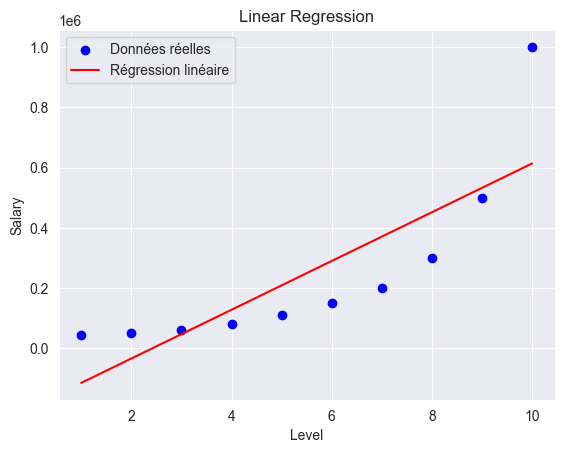

In [6]:
# Plot Linear Regression
plt.scatter(X, y, color="blue", label="Données réelles")
plt.plot(X, lr.predict(X), color="red", label="Régression linéaire")
plt.title("Linear Regression")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

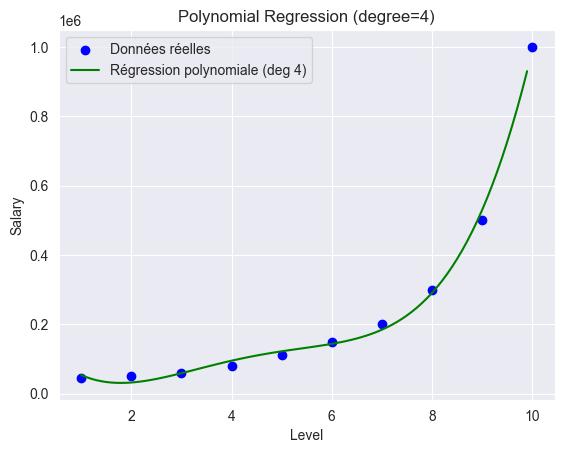

In [7]:
# Plot Polynomial Regression (courbe lisse)
X_grid = np.arange(X.min(), X.max(), 0.1)
X_grid = X_grid.reshape(-1, 1)

plt.scatter(X, y, color="blue", label="Données réelles")
plt.plot(X_grid, lr_2.predict(pr.transform(X_grid)), color="green", label="Régression polynomiale (deg 4)")
plt.title("Polynomial Regression (degree=4)")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [8]:
# Predict with linear regression 
print(f'Linear Regression result : {lr.predict([[7.5]])}')
# Predict with polynomial regression 
print(f'Polynomial Regression result : {lr_2.predict(pr.fit_transform([[7.5]]))}')

Linear Regression result : [411257.57575758]
Polynomial Regression result : [225126.29297787]
